This notebook implements the naive Mono-Forward Algorithm with the gradients


In [28]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


RESULTS_DIR = Path("results")
result_paths = sorted(RESULTS_DIR.glob("*.json"))

result_paths


[WindowsPath('results/mlp_mnist_20260429_123957.json')]

## Training and test losses


In [29]:
METHOD_LABELS = {
    "mono_ff": "MonoFWD FF",
    "mono_bp": "MonoFWD BP",
    "bp": "Backprop",
}


def load_experiment_history(path: Path) -> pd.DataFrame:
    with path.open() as f:
        raw = json.load(f)

    name_parts = path.stem.split("_")
    model = name_parts[0]
    dataset = name_parts[1]
    run_id = "_".join(name_parts[2:])

    rows = []
    for method, metrics in raw.items():
        if method not in METHOD_LABELS:
            continue

        max_train_epoch = len(metrics.get("train_losses", []))
        for metric, values in metrics.items():
            if not isinstance(values, list):
                continue

            is_final_test_metric = metric.startswith("test_") and len(values) == 1
            for index, value in enumerate(values, start=1):
                epoch = max_train_epoch if is_final_test_metric else index
                rows.append(
                    {
                        "file": path.name,
                        "model": model,
                        "dataset": dataset,
                        "run_id": run_id,
                        "method": method,
                        "method_label": METHOD_LABELS[method],
                        "metric": metric,
                        "epoch": epoch,
                        "value": value,
                        "is_final_test": is_final_test_metric,
                    }
                )

    return pd.DataFrame(rows)


history = pd.concat(
    [load_experiment_history(path) for path in result_paths],
    ignore_index=True,
)

losses = (
    history[history["metric"].isin(["train_losses", "val_losses", "test_losses"])]
    .copy()
    .assign(split=lambda df: df["metric"].str.replace("_losses", "", regex=False))
)

accuracies = (
    history[history["metric"].isin(["train_accs", "val_accs", "test_accs"])]
    .copy()
    .assign(split=lambda df: df["metric"].str.replace("_accs", "", regex=False))
)

display(losses.head())
display(
    history[history["metric"].str.startswith("train_")]
    .groupby(["dataset", "run_id", "method_label"])["epoch"]
    .max()
    .rename("trained_epochs")
    .to_frame()
)


,file,model,dataset,run_id,method,method_label,metric,epoch,value,is_final_test,split
0,mlp_mnist_20260429_123957.json,mlp,mnist,20260429_123957,mono_ff,MonoFWD FF,train_losses,1,0.277659,False,train
1,mlp_mnist_20260429_123957.json,mlp,mnist,20260429_123957,mono_ff,MonoFWD FF,train_losses,2,0.119457,False,train
2,mlp_mnist_20260429_123957.json,mlp,mnist,20260429_123957,mono_ff,MonoFWD FF,train_losses,3,0.077352,False,train
3,mlp_mnist_20260429_123957.json,mlp,mnist,20260429_123957,mono_ff,MonoFWD FF,train_losses,4,0.061722,False,train
4,mlp_mnist_20260429_123957.json,mlp,mnist,20260429_123957,mono_ff,MonoFWD FF,train_losses,5,0.040842,False,train


trained_epochs
dataset run_id          method_label                
mnist   20260429_123957 Backprop                  25
                        MonoFWD BP                27
                        MonoFWD FF                27

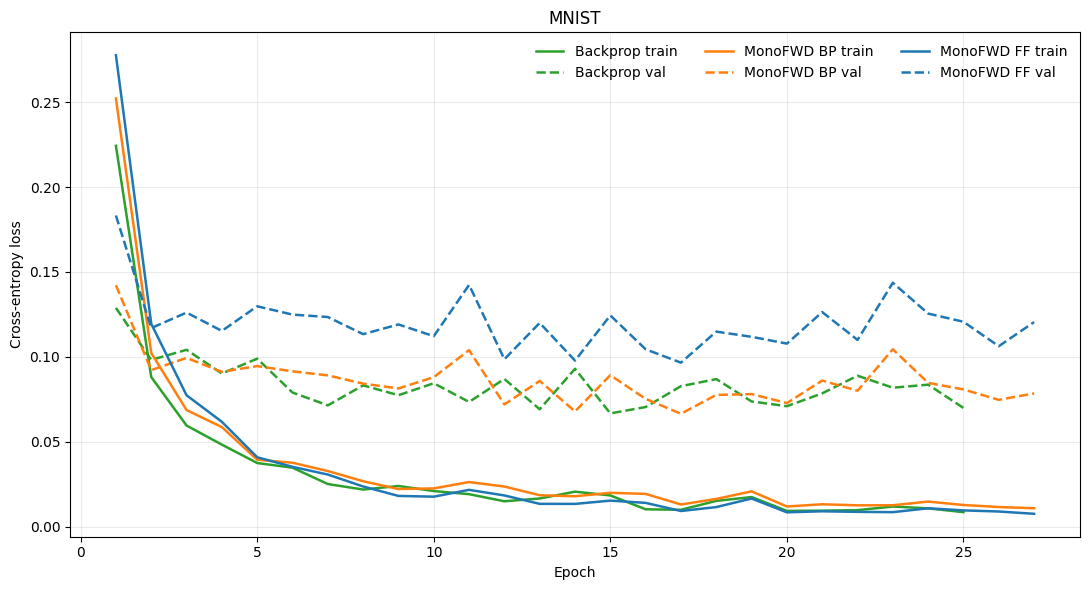

Test loss:
MNIST 20260429_123957 Backprop: 0.0635
MNIST 20260429_123957 MonoFWD BP: 0.0695
MNIST 20260429_123957 MonoFWD FF: 0.1006


In [ ]:
method_colors = {
    "MonoFWD FF": "tab:blue",
    "MonoFWD BP": "tab:orange",
    "Backprop": "tab:green",
}
split_styles = {"train": "-", "val": "--", "test": "None"}
split_markers = {"train": None, "val": None, "test": "o"}

for dataset in sorted(losses["dataset"].unique()):
    fig, ax = plt.subplots(figsize=(11, 6))
    dataset_losses = losses[
        (losses["dataset"] == dataset) & (losses["split"] != "test")
    ]

    for (method_label, split), group in dataset_losses.groupby(
        ["method_label", "split"]
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            marker=split_markers[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(dataset.upper())
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

print("Test loss:")
for _, row in (
    losses[losses["split"] == "test"]
    .sort_values(["dataset", "run_id", "method_label"])
    .iterrows()
):
    print(
        f"{row['dataset'].upper()} {row['run_id']} {row['method_label']}: "
        f"{row['value']:.4f}"
    )


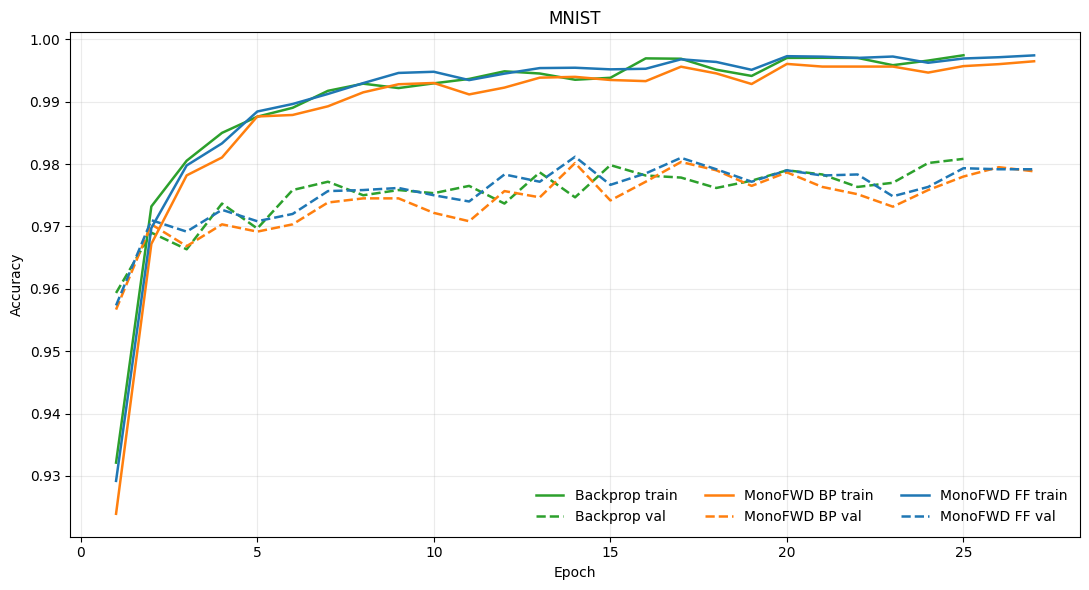

Test accuracy:
MNIST 20260429_123957 Backprop: 0.9817
MNIST 20260429_123957 MonoFWD BP: 0.9805
MNIST 20260429_123957 MonoFWD FF: 0.9818


In [ ]:
for dataset in sorted(accuracies["dataset"].unique()):
    fig, ax = plt.subplots(figsize=(11, 6))
    dataset_accuracies = accuracies[
        (accuracies["dataset"] == dataset) & (accuracies["split"] != "test")
    ]

    for (method_label, split), group in dataset_accuracies.groupby(
        ["method_label", "split"]
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            marker=split_markers[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(dataset.upper())
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

print("Test accuracy:")
for _, row in (
    accuracies[accuracies["split"] == "test"]
    .sort_values(["dataset", "run_id", "method_label"])
    .iterrows()
):
    print(
        f"{row['dataset'].upper()} {row['run_id']} {row['method_label']}: "
        f"{row['value']:.4f}"
    )
